# Differentialgleichungen II: Lineare DGL, Resonanz und Euler-DGL

Begleitendes Notebook zu *Angew.Mathe.1Differentialgleichungen_S14-27*: lineare Gleichungen erster und zweiter Ordnung, charakteristische Polynome, Resonanz und Euler-Differentialgleichungen.

**Voraussetzungen:** `numpy`, `sympy`, `matplotlib`  
**Arbeitsweise:** Zellen der Reihe nach ausführen und die Kontrollausgaben prüfen.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True

## 1. Lineare DGL erster Ordnung

Wir lösen $y'+2y=x^2$ mit SymPy und kontrollieren das Residuum.

In [2]:
x = sp.symbols('x', real=True)
yfun = sp.Function('y')
eq1 = sp.Eq(sp.diff(yfun(x), x) + 2*yfun(x), x**2)
sol1 = sp.dsolve(eq1)
display(sol1)
rhs1 = sol1.rhs
print('Residuum =', sp.simplify(sp.diff(rhs1, x) + 2*rhs1 - x**2))

Residuum = 0


## 2. Charakteristisches Polynom

Für $y''+3y'+2y=0$ sind die Nullstellen $-1$ und $-2$.

In [3]:
lam = sp.symbols('lambda')
poly = lam**2 + 3*lam + 2
roots = sp.solve(poly, lam)
print('p(lambda) =', sp.factor(poly))
print('Nullstellen:', roots)
C1, C2 = sp.symbols('C1 C2')
y_h = C1*sp.exp(-x) + C2*sp.exp(-2*x)
assert sp.simplify(sp.diff(y_h,x,2)+3*sp.diff(y_h,x)+2*y_h) == 0

p(lambda) = (lambda + 1)*(lambda + 2)
Nullstellen: [-2, -1]


## 3. Inhomogene DGL zweiter Ordnung

Für $y''+3y'+2y=\sin x$ bestimmen wir eine Lösung mit Anfangswerten $y(0)=0$, $y'(0)=0$.

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
C:\Users\kke\AppData\Local\Temp\ipykernel_54596\889859067.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(grid, np.sin(grid), '--', label='Anregung $\sin x$')


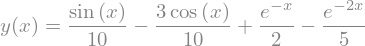

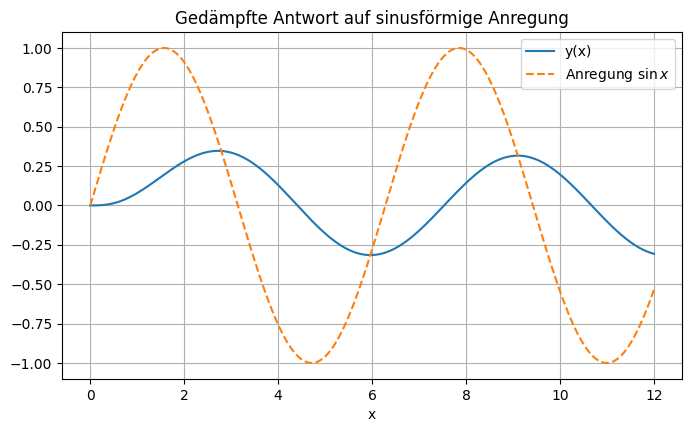

In [4]:
eq2 = sp.Eq(sp.diff(yfun(x),x,2)+3*sp.diff(yfun(x),x)+2*yfun(x), sp.sin(x))
sol2 = sp.dsolve(eq2, ics={yfun(0): 0, sp.diff(yfun(x),x).subs(x,0): 0})
display(sol2)
f2 = sp.lambdify(x, sol2.rhs, 'numpy')
grid = np.linspace(0, 12, 500)
plt.plot(grid, f2(grid), label='y(x)')
plt.plot(grid, np.sin(grid), '--', label='Anregung $\sin x$')
plt.xlabel('x'); plt.legend(); plt.title('Gedämpfte Antwort auf sinusförmige Anregung'); plt.show()

## 4. Resonanz beim Ansatz

Für $(D+1)^2y=e^{-x}$ ist $-1$ bereits eine doppelte Nullstelle. Ein partikulärer Ansatz benötigt daher den Faktor $x^2$.

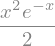

Residuum = 0


In [5]:
y_p = sp.Rational(1,2) * x**2 * sp.exp(-x)
res = sp.simplify(sp.diff(y_p,x,2)+2*sp.diff(y_p,x)+y_p-sp.exp(-x))
display(y_p)
print('Residuum =', res)
assert res == 0

## 5. Euler-Differentialgleichung

Für $x^2y''+3xy'+y=0$ besitzt das charakteristische Polynom $(\lambda+1)^2$ eine doppelte Nullstelle.

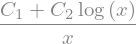

Residuum = 0


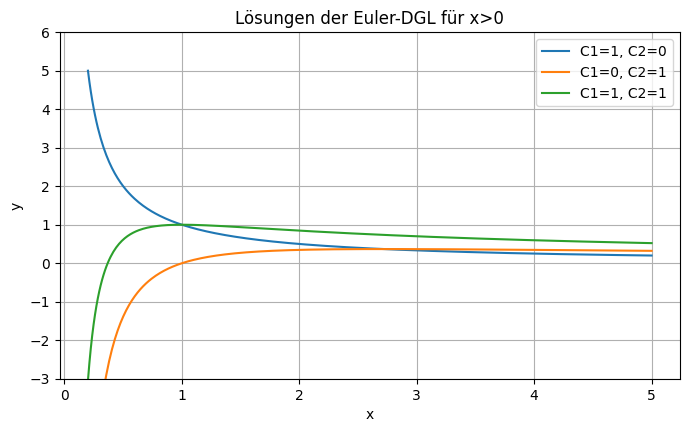

In [6]:
C1, C2 = sp.symbols('C1 C2')
y_e = (C1 + C2*sp.log(x))/x
res_e = sp.simplify(x**2*sp.diff(y_e,x,2)+3*x*sp.diff(y_e,x)+y_e)
display(y_e)
print('Residuum =', res_e)
assert res_e == 0

xx = np.linspace(0.2, 5, 400)
for c1, c2 in ((1,0), (0,1), (1,1)):
    yy = (c1 + c2*np.log(xx))/xx
    plt.plot(xx, yy, label=f'C1={c1}, C2={c2}')
plt.xlabel('x'); plt.ylabel('y'); plt.ylim(-3,6); plt.legend();
plt.title('Lösungen der Euler-DGL für x>0'); plt.show()

## Übungen

1. Löse $y'+3y=\sin(2x)$ symbolisch und prüfe durch Einsetzen.  
2. Vergleiche $y''+y=\sin x$ mit $y''+y=\sin(2x)$ hinsichtlich Resonanz.  
3. Löse $x^2y''-xy'+y=0$ mit dem Potenzansatz.